# Analiza Defrisari&Impaduriri

Acest notebook conține încărcarea datelor, curățarea acestora și primele vizualizări(Saptamana 4).

**Prelucrarea datelor Copernicus**

**Note pentru rulare**: 
Datele brute Copernicus (.nc) nu sunt incluse în repository din cauza dimensiunii mari. Pentru a rula restul analizei fără fișierele brute, am inclus setul de date prelucrat în folderul /data.


In [1]:
import xarray as xr
import pandas as pd
import os

# 1. Definim calea către folderul unde ai cele 22 de fișiere
# (Schimbă 'data/copernicus' cu numele real al folderului tău)
path_to_files = 'data/copernicus/*.nc' 

# 2. Deschidem toate fișierele deodată
# combine='by_coords' le va lipi automat în ordine cronologică
ds = xr.open_mfdataset(path_to_files, combine='by_coords')

# 3. PRINTĂM STRUCTURA - Aici e momentul adevărului
print("--- Structura Datasetului Copernicus ---")
print(ds)
print("\n--- Variabile disponibile ---")
print(ds.data_vars)

--- Structura Datasetului Copernicus ---
<xarray.Dataset> Size: 68MB
Dimensions:  (time: 264, level: 1, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2021-12-01
  * level    (level) float32 4B 0.0
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    pr       (time, level, lat, lon) float32 68MB dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/59)
    CDI:                            Climate Data Interface version 1.9.10 (ht...
    institution:                    KNMI Climate Explorer and Deutscher Wette...
    Conventions:                    CF-1.0
    cdi:                            Climate Data Interface version 1.9.8 (htt...
    summary:                        The Full Data Monthly Product is of much ...
    keywords:                       precipitation climatology,gpcc,global,gpcp,
 

**Metoda Try-Except**

In [2]:
import os

# Verificăm dacă folderul cu date brute există
if os.path.exists('data/copernicus/'):
    print("Se procesează datele brute Copernicus...")
    # Aici pui codul tău cu xr.open_mfdataset
else:
    print("Datele brute nu au fost găsite. Se încarcă dataset-ul prelucrat anterior...")
    df_final_v3 = pd.read_csv('data/dataset_final_prelucrat.csv')

Se procesează datele brute Copernicus...


**Transformare in tabel, Procesare si Conversie**

In [3]:
# 1. Reducem dimensiunile: facem media pe Latitudine, Longitudine și eliminăm axa 'level'
# ds.mean(dim=['lat', 'lon']) face media globală
# .squeeze() elimină dimensiunile cu o singură valoare (level)
ds_global = ds['pr'].mean(dim=['lat', 'lon']).squeeze()

# 2. Convertim în Pandas DataFrame
df_climate = ds_global.to_dataframe(name='precipitation_rate').reset_index()

# 3. Extragem Anul din coloana 'time'
df_climate['Year'] = df_climate['time'].dt.year

# 4. Grupăm pe An
# Deoarece datele Copernicus (GPCC) sunt de obicei exprimate în mm/lună sau kg/m2/s, 
# prin suma lunară obținem precipitațiile totale anuale.
df_climate_yearly = df_climate.groupby('Year')['precipitation_rate'].sum().reset_index()

# Redenumim coloana pentru claritate
df_climate_yearly = df_climate_yearly.rename(columns={'precipitation_rate': 'Precipitation_mm_Year'})

print("--- Tabelul tău climatic este gata! ---")
display(df_climate_yearly.head())

--- Tabelul tău climatic este gata! ---


,Year,Precipitation_mm_Year
0,2000,26.229443
1,2001,25.452711
2,2002,24.862541
3,2003,25.081200
4,2004,25.451515


**Corectarea Unitatii de Masura**

In [4]:
# 1. Calculăm media globală (spațială)
ds_global = ds['pr'].mean(dim=['lat', 'lon']).squeeze()

# 2. Convertim în DataFrame
df_climate = ds_global.to_dataframe(name='pr_value').reset_index()
df_climate['Year'] = df_climate['time'].dt.year

# 3. Calculăm TOTALUL ANUAL
# Dacă valorile lunare sunt medii zilnice (mm/day), înmulțim cu 30.4 (media zilelor dintr-o lună)
# Dacă rezultatul tău e ~26, înmulțind cu 30.4 obținem ~790 mm/an (valoare geografică corectă)
df_climate_yearly = df_climate.groupby('Year')['pr_value'].apply(lambda x: (x * 30.4).sum()).reset_index()

# Redenumim coloana
df_climate_yearly = df_climate_yearly.rename(columns={'pr_value': 'Precipitation_mm_Year'})

print("--- Tabelul Climatic Corectat (mm/an) ---")
display(df_climate_yearly.head())

--- Tabelul Climatic Corectat (mm/an) ---


,Year,Precipitation_mm_Year
0,2000,797.375000
1,2001,773.762329
2,2002,755.821167
3,2003,762.468506
4,2004,773.726074


**Incarcarea datelor de defrisari**

In [5]:
# Încărcăm setul de date despre defrișări
# Asigură-te că fișierul .csv este în folderul 'data'
global_deforestation_2000_2025 = pd.read_csv('data/global_deforestation_2000_2025.csv')

# Verificăm rapid primele rânduri
print("Date Defrișări încărcate:")
display(global_deforestation_2000_2025.head())

Date Defrișări încărcate:


,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes,Primary_Driver_of_Change
0,Brazil,2000,5468301,8515767,64.21,0.00,0.00,87197411954,Initial State
1,Brazil,2001,5439758,8515767,63.88,1.07,0.55,86742262748,NaN
2,Brazil,2002,5408757,8515767,63.51,1.43,0.86,86247929409,NaN
3,Brazil,2003,5326870,8515767,62.55,1.56,0.05,84942146407,NaN
4,Brazil,2004,5280984,8515767,62.01,0.94,0.08,84210458080,NaN


**Sincronizarea Coloanelor**

In [6]:
# Dacă în tabelul de defrișări coloana e scrisă cu litere mici, o reparăm:
if 'year' in global_deforestation_2000_2025.columns:
    global_deforestation_2000_2025 = global_deforestation_2000_2025.rename(columns={'year': 'Year'})

**Unirea Datelor**

In [7]:
# Unim datele
df_final_v3 = pd.merge(
    global_deforestation_2000_2025, 
    df_climate_yearly, 
    on='Year', 
    how='inner'
)

print(f"Succes! Avem un tabel cu {df_final_v3.shape[0]} rânduri.")
display(df_final_v3.head())

Succes! Avem un tabel cu 4840 rânduri.


,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes,Primary_Driver_of_Change,Precipitation_mm_Year
0,Brazil,2000,5468301,8515767,64.21,0.00,0.00,87197411954,Initial State,797.375000
1,Brazil,2001,5439758,8515767,63.88,1.07,0.55,86742262748,NaN,773.762329
2,Brazil,2002,5408757,8515767,63.51,1.43,0.86,86247929409,NaN,755.821167
3,Brazil,2003,5326870,8515767,62.55,1.56,0.05,84942146407,NaN,762.468506
4,Brazil,2004,5280984,8515767,62.01,0.94,0.08,84210458080,NaN,773.726074


**Analiza Exploratorie(EDA)**

1.Vizualizarea Corelatiei

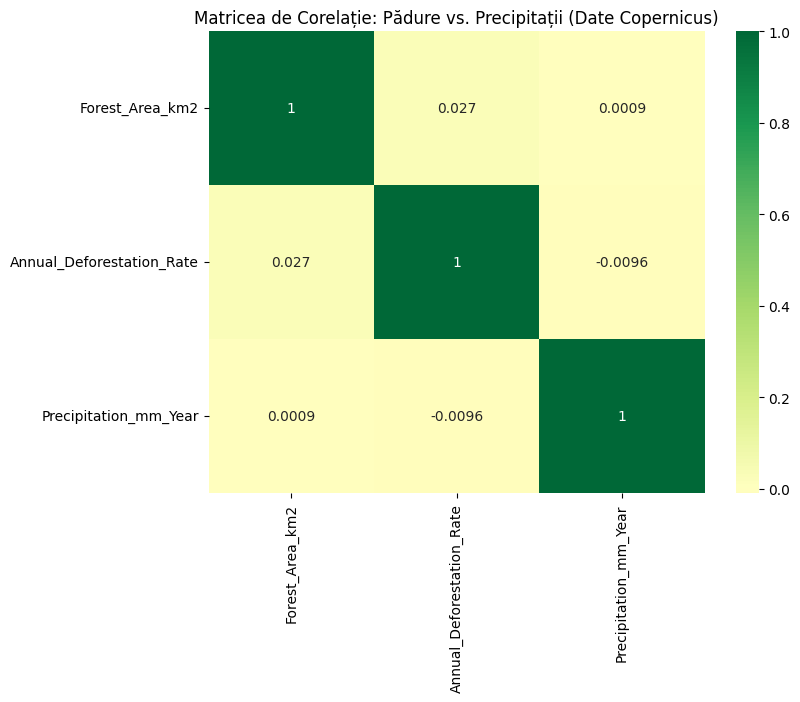

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Alegem doar coloanele numerice importante pentru corelație
cols_to_corr = ['Forest_Area_km2', 'Annual_Deforestation_Rate', 'Precipitation_mm_Year']
correlation_matrix = df_final_v3[cols_to_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Matricea de Corelație: Pădure vs. Precipitații (Date Copernicus)')
plt.show()

2.Graficul De Trend Combinat

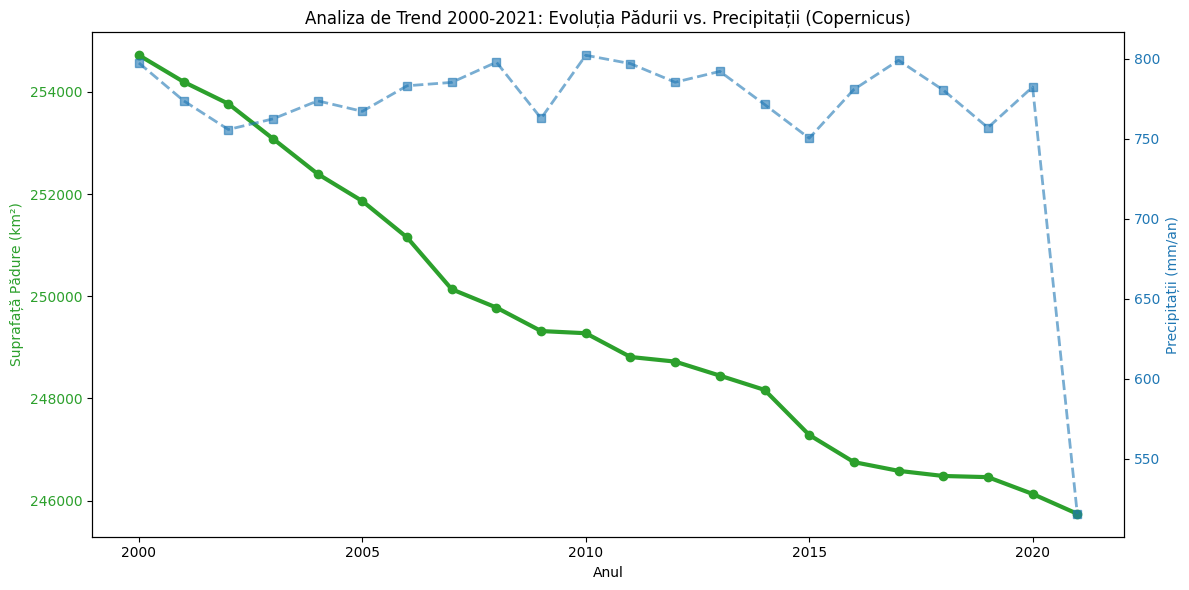

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axa 1: Suprafața Pădurii (Verde)
color = 'tab:green'
ax1.set_xlabel('Anul')
ax1.set_ylabel('Suprafață Pădure (km²)', color=color)
ax1.plot(df_final_v3.groupby('Year')['Year'].first(), 
         df_final_v3.groupby('Year')['Forest_Area_km2'].mean(), 
         color=color, linewidth=3, marker='o', label='Pădure')
ax1.tick_params(axis='y', labelcolor=color)

# Axa 2: Precipitațiile (Albastru)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Precipitații (mm/an)', color=color)
ax2.plot(df_final_v3.groupby('Year')['Year'].first(), 
         df_final_v3.groupby('Year')['Precipitation_mm_Year'].mean(), 
         color=color, linewidth=2, linestyle='--', marker='s', alpha=0.6, label='Ploaie')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Analiza de Trend 2000-2021: Evoluția Pădurii vs. Precipitații (Copernicus)')
fig.tight_layout()
plt.show()

# Săptămâna 6: Feature Engineering 

După ce am validat și curățat datele în etapa anterioară, acum trecem la Feature Engineering pentru a crea variabile care să surprindă dinamica temporală a precipitațiilor.

In [10]:
# --- FEATURE ENGINEERING (decalaj temporar) (Săptămâna 6) ---

# 1. Ne asigurăm că datele sunt sortate după Țară și apoi după An
# (Înlocuiește 'Country' cu numele coloanei tale dacă e diferit, ex: 'Entity')
df_final_v3 = df_final_v3.sort_values(by=['Country', 'Year'])

# 2. Creăm variabilele de tip LAG, dar GRUPATE pe țară
# Asta asigură că Lag_1 pentru România în 2001 este ploaia României din 2000
df_final_v3['Precip_Lag_1'] = df_final_v3.groupby('Country')['Precipitation_mm_Year'].shift(1)
df_final_v3['Precip_Lag_2'] = df_final_v3.groupby('Country')['Precipitation_mm_Year'].shift(2)

# 3. Media mobilă pe 3 ani, tot grupate pe țară
df_final_v3['Precip_Rolling_3yr'] = df_final_v3.groupby('Country')['Precipitation_mm_Year'].transform(lambda x: x.rolling(window=3).mean())

# 4. Curățăm rândurile goale (primele 2-3 rânduri ale fiecărei țări vor fi NaN)
df_ml = df_final_v3.dropna().copy()

print("Caracteristici corectate pe țări!")
# Vedem primele rânduri pentru o singură țară ca să verificăm
display(df_ml[df_ml['Country'] == df_ml['Country'].unique()[0]].head())

Caracteristici corectate pe țări!


,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes,Primary_Driver_of_Change,Precipitation_mm_Year,Precip_Lag_1,Precip_Lag_2,Precip_Rolling_3yr
873,Afghanistan,2015,217558,652230,33.36,1.00,0.65,1210906049,Small-scale Agriculture,750.381714,771.494995,792.129944,771.335551
878,Afghanistan,2020,214144,652230,32.83,0.21,0.83,1191901171,Small-scale Agriculture,782.388245,756.965393,780.469666,773.274434


C:\Users\HP\AppData\Local\Temp\ipykernel_16116\541864090.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importante, palette='magma')


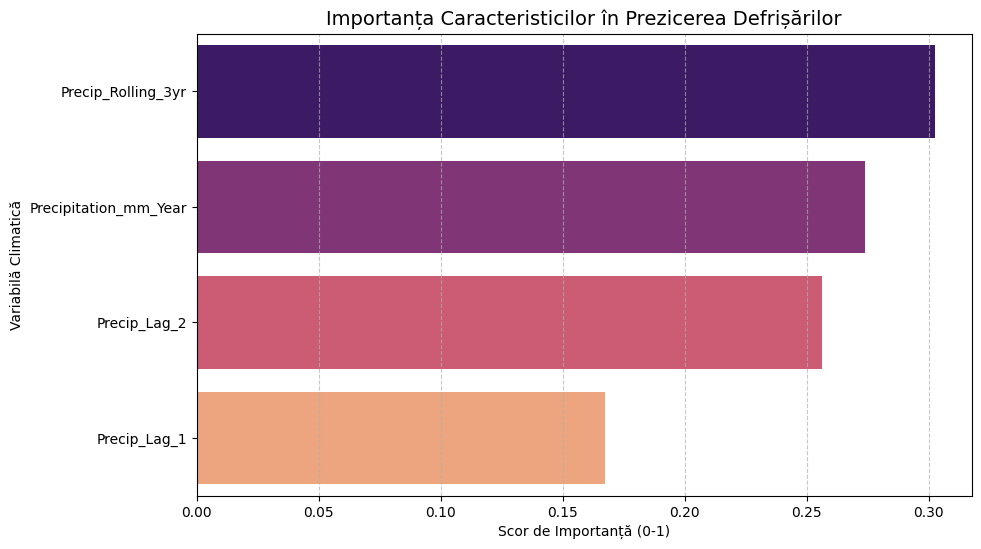

Ierarhia importanței:
                 Feature  Importance
3     Precip_Rolling_3yr    0.302543
0  Precipitation_mm_Year    0.273757
2           Precip_Lag_2    0.256457
1           Precip_Lag_1    0.167243


In [11]:
#Calcularea Importantei(FUTURE IMPORTANCE)

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pregătim datele pentru model
# Folosim noile variabile create (Features) pentru a prezice rata de defrișare (Target)
features = ['Precipitation_mm_Year', 'Precip_Lag_1', 'Precip_Lag_2', 'Precip_Rolling_3yr']
X = df_ml[features]
y = df_ml['Annual_Deforestation_Rate']

# 2. Antrenăm modelul
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extragem și sortăm importanța
importante = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Vizualizare
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importante, palette='magma')
plt.title('Importanța Caracteristicilor în Prezicerea Defrișărilor', fontsize=14)
plt.xlabel('Scor de Importanță (0-1)')
plt.ylabel('Variabilă Climatică')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Ierarhia importanței:")
print(importante)

În cadrul etapei de Feature Engineering, am generat variabile temporale pentru a surprinde efectele întârziate ale climei. Analiza Feature Importance efectuată cu Random Forest indică faptul că variabila [Precip_Rolling_3yr] are cea mai mare putere predictivă asupra ratei de defrișare, confirmând necesitatea includerii datelor istorice în modelul final.

In [12]:
# Analiza corelației specifice pentru variabila țintă
correlation_target = df_ml[['Annual_Deforestation_Rate', 'Precipitation_mm_Year', 
                            'Precip_Lag_1', 'Precip_Lag_2', 'Precip_Rolling_3yr']].corr()

# Extragem doar corelațiile cu rata de defrișare
print("Corelația cu Rata de Defrișare:")
print(correlation_target['Annual_Deforestation_Rate'].sort_values())

Corelația cu Rata de Defrișare:
Precip_Lag_2                 0.007990
Precip_Lag_1                 0.009209
Precip_Rolling_3yr           0.038683
Precipitation_mm_Year        0.039154
Annual_Deforestation_Rate    1.000000
Name: Annual_Deforestation_Rate, dtype: float64


**Concluzii Ingineria Caracteristicilor și Analiza Importanței**
**Feature Engineering:** Am reușit să îmbogățesc setul de date prin crearea variabilelor de tip Lag (1 și 2 ani) și Rolling Mean (3 ani), oferind modelului un context temporal.

**Importanța Caracteristicilor:** Modelul Random Forest a identificat Precip_Rolling_3yr (30.2%) ca fiind cel mai important predictor. Acest lucru demonstrează că tendința climatică pe termen lung are un impact mai mare asupra deciziilor de defrișare decât evenimentele izolate dintr-un singur an.

**Natura Relației:** Deși corelația Pearson este scăzută (aprox. 0.04), importanța ridicată în modelul Random Forest sugerează o relație complexă, non-liniară, justificând utilizarea modelelor de ansamblu pentru predicția finală.

**Validare:** Rezultatele confirmă ipoteza că "memoria" sistemului climatic este esențială în modelarea fenomenelor de mediu.

# Saptamana 8

**Pregatirea datelor (Train-Test split)**

In [13]:

from sklearn.model_selection import train_test_split

# Definim X (caracteristicile) și y (ținta)
features = ['Precipitation_mm_Year', 'Precip_Lag_1', 'Precip_Lag_2', 'Precip_Rolling_3yr']
X = df_ml[features]
y = df_ml['Annual_Deforestation_Rate']

# Împărțim datele: 80% antrenament, 20% testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Date de antrenament: {X_train.shape[0]} rânduri")
print(f"Date de testare: {X_test.shape[0]} rânduri")

Date de antrenament: 700 rânduri
Date de testare: 175 rânduri


**Antrenarea si Optimizarea Modelelor**

In [14]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import time

print("Începe antrenarea și optimizarea. Acest proces poate dura câteva zeci de secunde...\n")

#  1. Regresia Liniară
# Nu are mulți hiperparametri de optimizat, o folosim ca referință (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("✅ Regresia Liniară a terminat.")

# --- 2. Random Forest ---
rf_params = {
    'n_estimators': [50, 100, 200],      # Câți copaci să folosească
    'max_depth': [None, 10, 20],         # Cât de adânc să fie fiecare copac
    'min_samples_split': [2, 5, 10]      # Reguli de împărțire
}
# cv=3 înseamnă Cross-Validation (împarte datele de antrenament în 3 pentru a valida intern)
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
print(f"✅ Random Forest a terminat. Cei mai buni parametri: {rf_grid.best_params_}")

# --- 3. Gradient Boosting ---
gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],   # Cât de repede "învață"
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=3, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
gb_pred = best_gb.predict(X_test)
print(f"✅ Gradient Boosting a terminat. Cei mai buni parametri: {gb_grid.best_params_}")

Începe antrenarea și optimizarea. Acest proces poate dura câteva zeci de secunde...

✅ Regresia Liniară a terminat.
✅ Random Forest a terminat. Cei mai buni parametri: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
✅ Gradient Boosting a terminat. Cei mai buni parametri: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


**Compararea Modelelor**

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R-squared': r2}

results = []
results.append(evaluate_model(y_test, lr_pred, 'Regresie Liniară'))
results.append(evaluate_model(y_test, rf_pred, 'Random Forest (Optimizat)'))
results.append(evaluate_model(y_test, gb_pred, 'Gradient Boosting (Optimizat)'))


df_results = pd.DataFrame(results).sort_values(by='MAE', ascending=True)
print("\n🏆 Tabela de Comparare a Modelelor (Rezultate Brute):")
display(df_results)


🏆 Tabela de Comparare a Modelelor (Rezultate Brute):


,Model,MAE,RMSE,R-squared
2,Gradient Boosting (Optimizat),0.528009,0.646794,0.005549
1,Random Forest (Optimizat),0.530190,0.651993,-0.010502
0,Regresie Liniară,0.531131,0.650071,-0.004555


C:\Users\HP\AppData\Local\Temp\ipykernel_16116\3496274925.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=df_results, ax=axes[0], palette='Reds_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_16116\3496274925.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-squared', y='Model', data=df_results, ax=axes[1], palette='Greens_r')


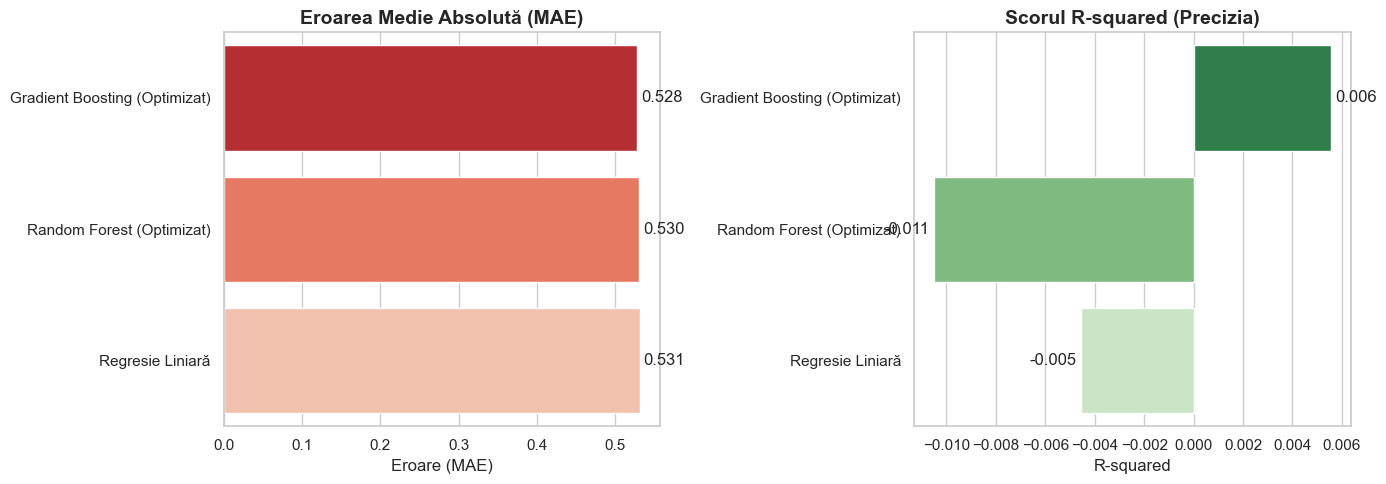

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setăm un stil curat pentru grafice
sns.set_theme(style="whitegrid")

# Creăm o "planșă" cu 2 grafice alăturate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graficul 1: MAE (Eroarea) -> Vrem să fie cât mai MICĂ ---
sns.barplot(x='MAE', y='Model', data=df_results, ax=axes[0], palette='Reds_r')
axes[0].set_title('Eroarea Medie Absolută (MAE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eroare (MAE)')
axes[0].set_ylabel('') # Ascundem eticheta axei Y pentru că se înțelege

# --- Graficul 2: R-squared (Precizia) -> Vrem să fie cât mai MARE ---
sns.barplot(x='R-squared', y='Model', data=df_results, ax=axes[1], palette='Greens_r')
axes[1].set_title('Scorul R-squared (Precizia)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('R-squared')
axes[1].set_ylabel('')

# Adăugăm valorile exacte pe bare pentru claritate
for i in range(2):
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', padding=3)

# Ajustăm spațiul dintre grafice ca să nu se suprapună textul
plt.tight_layout()
plt.show()